-	Project day: House Price Prediction on Kaggle
-	XGBoost + Optuna tuning : document exactly what each change did to your score
-	Try feature engineering: log-transform skewed features, add interaction terms


# **week4 Project**

In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv("train.csv")


In [10]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [12]:
null_cols = df.isnull().sum()
null_cols[null_cols > 0].sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [13]:
#drop cols > 50% null count
df = df.drop(columns=["PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType"])

In [15]:
#Fill na values of numeric columns with median
for cols in df.select_dtypes(include='number').columns:
  df[cols] = df[cols].fillna(df[cols].median())

In [16]:
#fill categorical columns with mode
for cols in df.select_dtypes(include='object').columns:
  df[cols] = df[cols].fillna(df[cols].mode()[0])

In [17]:
#encode categoricals with pd.get_dummies()
df = pd.get_dummies(df)

In [18]:
df

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,True,False,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,True,False,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,True,False,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,True,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,False,False,False,True,False,False,False,False,True,False
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,False,False,False,True,False,False,False,False,True,False
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,False,False,False,True,False,False,False,False,True,False
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,False,False,False,True,False,False,False,False,True,False


In [19]:
X = df.drop(columns=['SalePrice'])
y=df['SalePrice']

In [20]:
print(f"X shape: {X.shape}")
print(f"\ny shape: {y.shape}")

X shape: (1460, 272)

y shape: (1460,)


## Task 1: Optuna on XGBoost for House Prices
1. Same objective function as Day 5 but use XGBRegressor and scoring='neg_mean_squared_error'.
2. Run 50 trials, print best params and RMSE.


In [24]:
from xgboost import XGBRegressor

In [21]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.3 MB/s eta 0:00:00


In [23]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [29]:
from sklearn.model_selection import cross_val_score
#objective function
def objective(trial):

  #optuna suggests trials:
  n_estimators = trial.suggest_int('n_estimators',100, 500)
  max_depth = trial.suggest_int('max_depth', 3,9)
  learning_rate = trial.suggest_float('learning_rate', 0.01,0.3)

  #define model with suggested params
  model = XGBRegressor(
      n_estimators = n_estimators,
      max_depth = max_depth,
      learning_rate = learning_rate,
  )
  score = cross_val_score(model, X, y,cv=5, scoring='neg_mean_squared_error')
  return np.mean(score)

In [30]:
#50 trial study
study = optuna.create_study(direction="maximize")
study.optimize(objective,n_trials=50)

In [31]:
#best_params, best_value
print(study.best_params)
print(study.best_value)

{'n_estimators': 417, 'max_depth': 3, 'learning_rate': 0.13476041575471429}
-691958969.6


In [32]:
print(f"Optuna RMSE: {np.sqrt(abs(study.best_value)):.0f}")

Optuna RMSE: 26305


## Task 2: Log-transform skewed features
1. SalePrice is heavily right-skewed :log-transform it before training.
2. Also check LotArea and GrLivArea for skew.


SalePrice Skew: 1.88


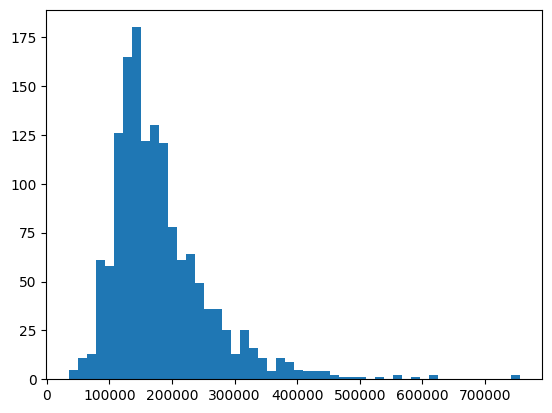

In [35]:
import matplotlib.pyplot as plt
print(f"SalePrice Skew: {y.skew():.2f}")
plt.hist(y, bins=50)
plt.show()

## Right skewed
1. Long tail pushing towards "\$700,000", with most houses clustered around
\$100k - \$200k
2. Skew of 1.88 is significant -> anything above 0.5 is worth transforming

Log SalePrice Skew: 0.12


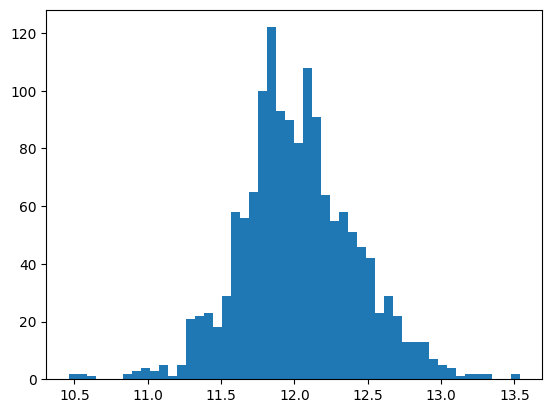

In [36]:
#log transform
y_log = np.log1p(y)
print(f"Log SalePrice Skew: {y_log.skew():.2f}")
plt.hist(y_log, bins=50)
plt.show()

## Skew dropped from 1.88 to 0.12
1.  nearly perfect normal distribution now.

In [40]:
#objective function with log_transform on SalePrice (y_log)
def objective_log(trial):

  #optuna suggests trials:
  n_estimators = trial.suggest_int('n_estimators',100, 500)
  max_depth = trial.suggest_int('max_depth', 3,9)
  learning_rate = trial.suggest_float('learning_rate', 0.01,0.3)

  #define model with suggested params
  model = XGBRegressor(
      n_estimators = n_estimators,
      max_depth = max_depth,
      learning_rate = learning_rate,
  )
  score = cross_val_score(model, X, y_log,cv=5, scoring='neg_mean_squared_error')
  return np.mean(score)

In [41]:
#50 trial study
study1 = optuna.create_study(direction="maximize")
study1.optimize(objective_log,n_trials=50)

In [42]:
#best_params, best_value
print(study1.best_params)
print(study1.best_value)

{'n_estimators': 183, 'max_depth': 3, 'learning_rate': 0.09876869017440497}
-0.015545937083858614


In [44]:
# predictions on log scale, convert back to dollars
best_model = XGBRegressor(**study1.best_params)

from sklearn.model_selection import cross_val_predict

y_pred_log = cross_val_predict(best_model, X, y_log, cv=5)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_log)

In [45]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
print(f"RMSE after log-transform: ${rmse:,.0f}")

RMSE after log-transform: $27,309


Task 3  Kaggle submission
1. Download test.csv from House Prices competition, apply same cleaning + feature engineering, predict, submit.


In [71]:
test_df = pd.read_csv('test.csv')

In [72]:
null_test_cols = test_df.isnull().sum()
null_test_cols[null_test_cols > 0].sort_values(ascending=False)

,0
PoolQC,1456
MiscFeature,1408
Alley,1352
Fence,1169
MasVnrType,894
FireplaceQu,730
LotFrontage,227
GarageQual,78
GarageCond,78
GarageYrBlt,78


In [73]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [74]:
# drop high null columns
test_df = test_df.drop(columns=["PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType"])

# fill numeric
for col in test_df.select_dtypes(include='number').columns:
    test_df[col] = test_df[col].fillna(test_df[col].median())

# fill categorical
for col in test_df.select_dtypes(include='object').columns:
    test_df[col] = test_df[col].fillna(test_df[col].mode()[0])

# encode
test_df = pd.get_dummies(test_df)

# align with training columns
X_test = test_df.reindex(columns=X.columns, fill_value=0)
print(X_test.shape)

(1459, 272)


In [75]:
test_df.shape

(1459, 256)

In [76]:
test_df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1461,20,80.0,11622,5,6,1961,1961,0.0,468.0,...,False,False,False,True,False,False,False,False,True,False
1,1462,20,81.0,14267,6,6,1958,1958,108.0,923.0,...,False,False,False,True,False,False,False,False,True,False
2,1463,60,74.0,13830,5,5,1997,1998,0.0,791.0,...,False,False,False,True,False,False,False,False,True,False
3,1464,60,78.0,9978,6,6,1998,1998,20.0,602.0,...,False,False,False,True,False,False,False,False,True,False
4,1465,120,43.0,5005,8,5,1992,1992,0.0,263.0,...,False,False,False,True,False,False,False,False,True,False


In [77]:
best_model_house_price = XGBRegressor(**study.best_params)
best_model_house_price.fit(X,y)

predictions  = best_model_house_price.predict(X_test)
submission = pd.DataFrame({
  'Id':test_df['Id'],
  'SalePrice':predictions
})
submission.to_csv('submission.csv', index=False)
print(submission.head())

     Id      SalePrice
0  1461  121622.734375
1  1462  173085.609375
2  1463  171411.062500
3  1464  189681.828125
4  1465  181776.093750


Task 4:
Markdown table showing what each change did to RMSE.

## What Each Change Did to RMSE

| Change | RMSE | Delta |
|--------|------|-------|
| XGBoost baseline (Day 3)| \$29,412 | — |
| LightGBM baseline (Day 3) | \$28,809 | -\$603 |
| XGBoost + Optuna 50 trials | \$26,305 | -\$3,107 |
| XGBoost + Optuna + log-transform | \$27,309 | +\$1,004 ↑ worse |
| Kaggle submission (XGBoost + Optuna) | 14,713 | — |

1. Key insight: Optuna tuning gave the biggest improvement ($3,107).
2. Log-transform hurt XGBoost slightly :
    1. tree models are less sensitive to skew than linear models since they split on thresholds not distances.